# Model Experiments

This notebook runs a few lightweight HOG + SVM experiments using the project scripts in `src`. It is meant for comparison and reporting, while the main training pipeline stays in `src/train.py`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from config import CLASS_LABELS, SVM_CONFIG
from dataset import load_dataset

plt.style.use("default")
sns.set_theme(style="whitegrid")

## Load HOG Features

In [2]:
X, y = load_dataset()

print(f"Feature matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Classes: {CLASS_LABELS}")

Loading class_0 from C:\Users\shiva\OneDrive\Desktop\computer vision\computer vision projects\HOG_SVM_Classification\data\raw\train\class_0
  Loaded 310 images from class_0
Loading class_1 from C:\Users\shiva\OneDrive\Desktop\computer vision\computer vision projects\HOG_SVM_Classification\data\raw\train\class_1
  Loaded 310 images from class_1

Total dataset: 620 samples, 34596 features
Feature matrix: (620, 34596)
Labels: (620,)
Classes: ['class_0', 'class_1']


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 496
Validation samples: 124


## Try A Few SVM Settings

In [4]:
experiments = [
    {"name": "linear_C0.1", "kernel": "linear", "C": 0.1, "gamma": "scale"},
    {"name": "linear_C1", "kernel": "linear", "C": 1.0, "gamma": "scale"},
    {"name": "linear_C10", "kernel": "linear", "C": 10.0, "gamma": "scale"},
    {"name": "rbf_C1", "kernel": "rbf", "C": 1.0, "gamma": "scale"},
]

results = []
trained_models = {}

for experiment in experiments:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel=experiment["kernel"],
                C=experiment["C"],
                gamma=experiment["gamma"],
                probability=SVM_CONFIG.get("probability", True),
                random_state=SVM_CONFIG.get("random_state", 42),
            ),
        ),
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results.append({
        "experiment": experiment["name"],
        "kernel": experiment["kernel"],
        "C": experiment["C"],
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_val, y_pred, average="weighted", zero_division=0),
        "f1_score": f1_score(y_val, y_pred, average="weighted", zero_division=0),
    })
    trained_models[experiment["name"]] = model

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
results_df

,experiment,kernel,C,accuracy,precision,recall,f1_score
3,rbf_C1,rbf,1.0,0.677419,0.677604,0.677419,0.677335
0,linear_C0.1,linear,0.1,0.669355,0.669399,0.669355,0.669333
1,linear_C1,linear,1.0,0.669355,0.669399,0.669355,0.669333
2,linear_C10,linear,10.0,0.669355,0.669399,0.669355,0.669333


## Compare Experiment Scores

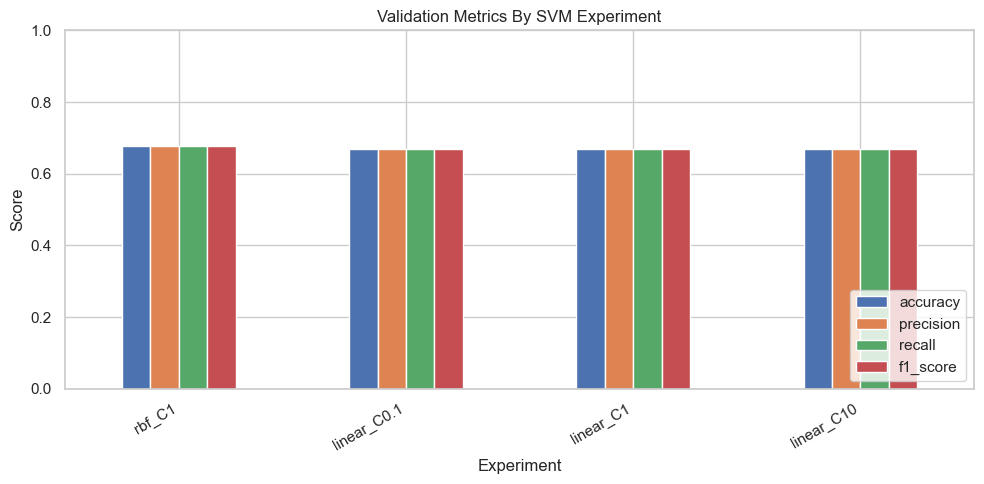

In [5]:
score_columns = ["accuracy", "precision", "recall", "f1_score"]
plot_df = results_df.set_index("experiment")[score_columns]

ax = plot_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
ax.set_title("Validation Metrics By SVM Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Confusion Matrix For The Best Experiment

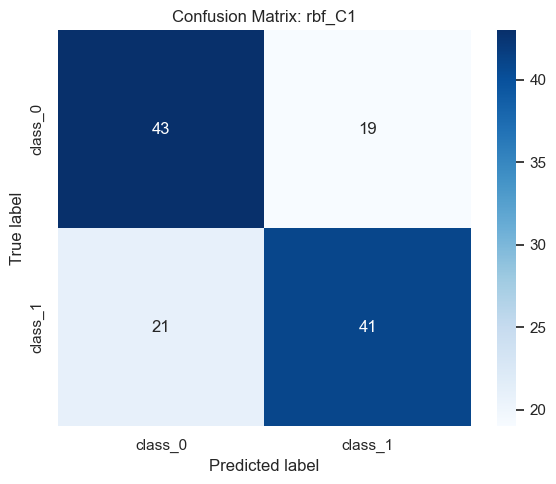

Best experiment: rbf_C1


In [6]:
best_experiment = results_df.iloc[0]["experiment"]
best_model = trained_models[best_experiment]
best_predictions = best_model.predict(X_val)
cm = confusion_matrix(y_val, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
)
plt.title(f"Confusion Matrix: {best_experiment}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(f"Best experiment: {best_experiment}")

## Notes

Use the best-performing settings here to update `src/config.py` or to guide a final training run from `src/train.py`.